# Sentiment Analysis Pipeline
### NLP Feature Representations × Classifiers × Evaluation

**Columns:** `review_id`, `source`, `product_category`, `review_text`, `cleaned_text`, `tokens`, `token_count`, `rating`, `label`  
**Feature Representations:** TF-IDF (unigrams + bigrams) · Word2Vec (averaged embeddings) · DistilBERT (fine-tuned)  
**Classifiers:** Logistic Regression · Linear SVM · Naive Bayes · Random Forest · DistilBERT  
**Pipeline:** Load → Features → Baseline → Tuning → Top Features → Error Analysis → Report


### Imports & Setup

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection         import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model            import LogisticRegression
from sklearn.svm                     import LinearSVC
from sklearn.naive_bayes             import MultinomialNB, GaussianNB
from sklearn.metrics                 import (accuracy_score, precision_score,
                                             recall_score, f1_score,
                                             confusion_matrix, classification_report)
from sklearn.preprocessing           import LabelEncoder
from gensim.models                   import Word2Vec

print("✅  All libraries imported successfully.")


✅  All libraries imported successfully.


### Load & Inspect Data

Expected columns: `review_id`, `source`, `product_category`, `review_text`,
`cleaned_text`, `tokens` (pipe-separated string), `token_count`, `rating`, `label`


In [2]:
INPUT_FILE = "reviews_preprocessed.csv"
df = pd.read_csv(INPUT_FILE)

# Drop rows missing required fields
df.dropna(subset=["cleaned_text", "label"], inplace=True)
df["cleaned_text"] = df["cleaned_text"].astype(str)

# tokens column is stored as a pipe-separated string ("word | word | word")
# Convert to a proper list of tokens
df["tokens"] = df["tokens"].astype(str).apply(
    lambda s: [t.strip() for t in s.split("|") if t.strip()]
)

print(f"📂  Loaded {len(df):,} reviews")
print(f"\nColumns : {list(df.columns)}")
print(f"\nLabel distribution:\n{df['label'].value_counts()}")
print(f"\nClass balance (%):\n{df['label'].value_counts(normalize=True).mul(100).round(2)}")
print(f"\nRating distribution:\n{df['rating'].value_counts().sort_index()}")
print(f"\nZero-length token lists: {df['tokens'].apply(len).eq(0).sum()}")
display(df[["review_id", "source", "product_category", "rating", "label", "cleaned_text"]].head())


📂  Loaded 30,000 reviews

Columns : ['review_id', 'source', 'product_category', 'review_text', 'cleaned_text', 'tokens', 'token_count', 'rating', 'label']

Label distribution:
label
negative    10000
positive    10000
neutral     10000
Name: count, dtype: int64

Class balance (%):
label
negative    33.33
positive    33.33
neutral     33.33
Name: proportion, dtype: float64

Rating distribution:
rating
1     7397
2     2603
3    10000
4     3697
5     6303
Name: count, dtype: int64

Zero-length token lists: 0


,review_id,source,product_category,rating,label,cleaned_text
0,REV00001,Google Play Store,Games - Battle Royale,2,negative,wonderfull game please fix voice glitch happen...
1,REV00002,Google Play Store,Games - Social Deduction,4,positive,great concept amount people quit midway game n...
2,REV00003,Google Play Store,Games - Augmented Reality,4,positive,game keep force close battle even catch pokémo...
3,REV00004,Google Play Store,Games - Shooter,5,positive,'s currently bug game make thing go completely...
4,REV00005,Google Play Store,Games - Strategy,2,negative,stupid game give first arena easly second play...


### Label Encoding & Train/Test Split (Stratified 80/20)

In [3]:
LABELS = sorted(df["label"].unique().tolist())   # derived from data
print(f"Classes found in data: {LABELS}")

le = LabelEncoder()
le.fit(LABELS)
y      = le.transform(df["label"])
X_text = df["cleaned_text"].values

# Stratified 80/20 split — record original indices for error analysis
all_indices = np.arange(len(df))
train_pos, test_pos = train_test_split(
    all_indices, test_size=0.20, random_state=42, stratify=y
)

X_train_text = X_text[train_pos]
X_test_text  = X_text[test_pos]
y_train      = y[train_pos]
y_test       = y[test_pos]

print(f"\n✂️  Train : {len(X_train_text):,}  |  Test : {len(X_test_text):,}")
print(f"Train label dist : { {l: int((y_train == i).sum()) for i, l in enumerate(LABELS)} }")
print(f"Test  label dist : { {l: int((y_test  == i).sum()) for i, l in enumerate(LABELS)} }")


Classes found in data: ['negative', 'neutral', 'positive']

✂️  Train : 24,000  |  Test : 6,000
Train label dist : {'negative': 8000, 'neutral': 8000, 'positive': 8000}
Test  label dist : {'negative': 2000, 'neutral': 2000, 'positive': 2000}


### Feature Representation 1 — TF-IDF (unigrams + bigrams)

Built from `cleaned_text`. Fit only on train to prevent leakage.


In [4]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),   # unigrams + bigrams
    max_features=20_000,
    sublinear_tf=True,    # log(tf)+1 smoothing
    min_df=2,
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf  = tfidf.transform(X_test_text)

print(f"✅  TF-IDF vocab : {len(tfidf.vocabulary_):,} features")
print(f"    Train matrix : {X_train_tfidf.shape}")
print(f"    Test  matrix : {X_test_tfidf.shape}")


✅  TF-IDF vocab : 20,000 features
    Train matrix : (24000, 20000)
    Test  matrix : (6000, 20000)


### Feature Representation 2 — Word2Vec (Averaged Embeddings)

Uses the pre-tokenised `tokens` column (pipe-separated → list).
Word2Vec is trained on the full corpus (unsupervised step — no label leakage).
Each document is represented as the mean of its word vectors.


In [5]:
all_token_lists = df["tokens"].tolist()   # list of lists

W2V_DIM = 100
w2v_model = Word2Vec(
    sentences=all_token_lists,
    vector_size=W2V_DIM,
    window=5,
    min_count=1,
    workers=4,
    seed=42,
    epochs=10,
)
print(f"✅  Word2Vec vocab : {len(w2v_model.wv):,} words  |  dim = {W2V_DIM}")

def tokens_to_w2v(token_lists):
    """Average word vectors for a list of token lists."""
    vecs = []
    for tokens in token_lists:
        valid = [w2v_model.wv[t] for t in tokens if t in w2v_model.wv]
        vecs.append(np.mean(valid, axis=0) if valid else np.zeros(W2V_DIM))
    return np.array(vecs)

# Use train token lists only (indexed by position)
train_tokens = df["tokens"].iloc[train_pos].tolist()
test_tokens  = df["tokens"].iloc[test_pos].tolist()

X_train_w2v = tokens_to_w2v(train_tokens)
X_test_w2v  = tokens_to_w2v(test_tokens)

# Non-negative shift for MultinomialNB; use TRAIN min to avoid leakage
w2v_min = X_train_w2v.min()
X_train_w2v_nn = X_train_w2v - w2v_min
X_test_w2v_nn  = X_test_w2v  - w2v_min

print(f"    Train W2V shape : {X_train_w2v.shape}")
print(f"    Test  W2V shape : {X_test_w2v.shape}")
print(f"    Zero vectors in test : {(X_test_w2v == 0).all(axis=1).sum()}")


✅  Word2Vec vocab : 19,707 words  |  dim = 100
    Train W2V shape : (24000, 100)
    Test  W2V shape : (6000, 100)
    Zero vectors in test : 0


### Evaluation & Helper Functions

In [6]:
def evaluate_model(model, X_train, X_test, y_train, y_test,
                   vectorizer=None, model_name="Model"):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec  = recall_score   (y_test, y_pred, average="macro", zero_division=0)
    f1m  = f1_score       (y_test, y_pred, average="macro", zero_division=0)
    cm   = confusion_matrix(y_test, y_pred)
    cr   = classification_report(y_test, y_pred, target_names=LABELS, zero_division=0)

    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc:.4f}  |  F1-Macro : {f1m:.4f}")
    print(f"\n{cr}")

    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=LABELS, yticklabels=LABELS,
                linewidths=0.5, ax=ax, cbar=False)
    ax.set_title(model_name, fontsize=10, fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    plt.tight_layout(); plt.show()

    return {"name": model_name, "clf": model, "y_pred": y_pred,
            "acc": acc, "prec": prec, "rec": rec, "f1_macro": f1m,
            "cm": cm, "report": cr}


def show_top_features(model, vectorizer, model_name="Model", top_n=15):
    print(f"\n{'='*55}")
    print(f"  TOP FEATURES — {model_name}")
    print(f"{'='*55}")
    if not hasattr(model, "coef_"):
        print("  ⚠️  Model does not expose coefficients.")
        return
    feature_names = np.array(vectorizer.get_feature_names_out())
    for i, label in enumerate(LABELS):
        coefs = model.coef_[i] if model.coef_.ndim > 1 else model.coef_[0]
        top_pos = feature_names[np.argsort(coefs)[-top_n:]][::-1]
        top_neg = feature_names[np.argsort(coefs)[:top_n]]
        print(f"\n  [{label.upper()}]")
        print(f"    Most positive : {', '.join(top_pos)}")
        print(f"    Most negative : {', '.join(top_neg)}")


def error_analysis(model, X_test_vec, y_test_enc, model_name="Model", n=10):
    print(f"\n{'='*55}")
    print(f"  ERROR ANALYSIS — {model_name}")
    print(f"{'='*55}")
    y_pred = model.predict(X_test_vec)
    mis    = np.where(y_pred != y_test_enc)[0]
    print(f"  Total misclassified : {len(mis):,}  |  Showing {min(n, len(mis))}\n")
    for k, pos in enumerate(mis[:n]):
        true_label = le.inverse_transform([y_test_enc[pos]])[0]
        pred_label = le.inverse_transform([y_pred[pos]])[0]
        orig_idx   = test_pos[pos]
        review     = df.iloc[orig_idx]["cleaned_text"]
        rating     = df.iloc[orig_idx]["rating"]
        print(f"  [{k+1:02d}]  TRUE: {true_label:<10}  PRED: {pred_label:<10}  Rating: {rating}")
        print(f"       {str(review)[:250]}")
        print()


print("✅  Helper functions defined.")


✅  Helper functions defined.


## Baseline Models (Default Hyperparameters)

### Logistic Regression


  LR + TF-IDF (baseline)
  Accuracy  : 0.6328  |  F1-Macro : 0.6320

              precision    recall  f1-score   support

    negative       0.66      0.70      0.68      2000
     neutral       0.52      0.50      0.51      2000
    positive       0.72      0.70      0.71      2000

    accuracy                           0.63      6000
   macro avg       0.63      0.63      0.63      6000
weighted avg       0.63      0.63      0.63      6000



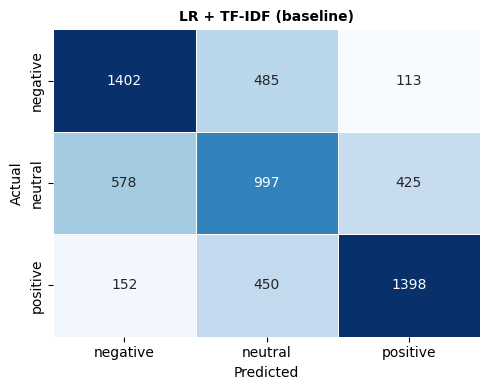


  LR + Word2Vec (baseline)
  Accuracy  : 0.6025  |  F1-Macro : 0.6005

              precision    recall  f1-score   support

    negative       0.63      0.68      0.65      2000
     neutral       0.48      0.45      0.46      2000
    positive       0.68      0.68      0.68      2000

    accuracy                           0.60      6000
   macro avg       0.60      0.60      0.60      6000
weighted avg       0.60      0.60      0.60      6000



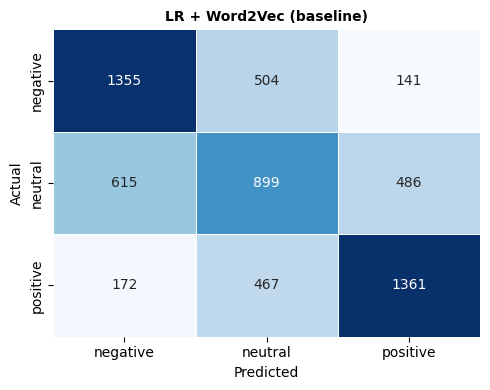

In [7]:
all_results = []

r = evaluate_model(LogisticRegression(max_iter=1000, random_state=42),
                   X_train_tfidf, X_test_tfidf, y_train, y_test,
                   vectorizer=tfidf, model_name="LR + TF-IDF (baseline)")
all_results.append(r)

r = evaluate_model(LogisticRegression(max_iter=1000, random_state=42),
                   X_train_w2v, X_test_w2v, y_train, y_test,
                   model_name="LR + Word2Vec (baseline)")
all_results.append(r)


### Linear SVM


  SVM + TF-IDF (baseline)
  Accuracy  : 0.6008  |  F1-Macro : 0.5982

              precision    recall  f1-score   support

    negative       0.62      0.67      0.65      2000
     neutral       0.49      0.45      0.46      2000
    positive       0.68      0.69      0.68      2000

    accuracy                           0.60      6000
   macro avg       0.60      0.60      0.60      6000
weighted avg       0.60      0.60      0.60      6000



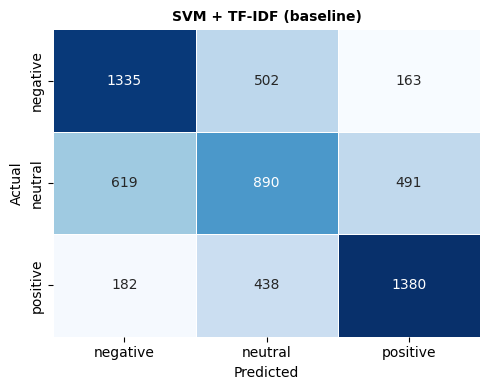


  SVM + Word2Vec (baseline)
  Accuracy  : 0.5983  |  F1-Macro : 0.5870

              precision    recall  f1-score   support

    negative       0.61      0.72      0.66      2000
     neutral       0.50      0.36      0.42      2000
    positive       0.65      0.71      0.68      2000

    accuracy                           0.60      6000
   macro avg       0.59      0.60      0.59      6000
weighted avg       0.59      0.60      0.59      6000



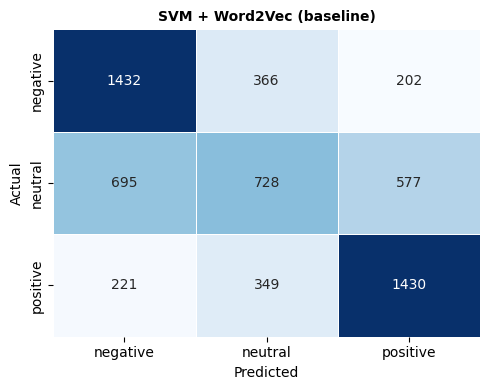

In [8]:
r = evaluate_model(LinearSVC(C=1.0, max_iter=3000, random_state=42),
                   X_train_tfidf, X_test_tfidf, y_train, y_test,
                   vectorizer=tfidf, model_name="SVM + TF-IDF (baseline)")
all_results.append(r)

r = evaluate_model(LinearSVC(C=1.0, max_iter=3000, random_state=42),
                   X_train_w2v, X_test_w2v, y_train, y_test,
                   model_name="SVM + Word2Vec (baseline)")
all_results.append(r)


### Naive Bayes


  NB MultinomialNB + TF-IDF (baseline)
  Accuracy  : 0.6125  |  F1-Macro : 0.6123

              precision    recall  f1-score   support

    negative       0.64      0.66      0.65      2000
     neutral       0.49      0.49      0.49      2000
    positive       0.71      0.69      0.70      2000

    accuracy                           0.61      6000
   macro avg       0.61      0.61      0.61      6000
weighted avg       0.61      0.61      0.61      6000



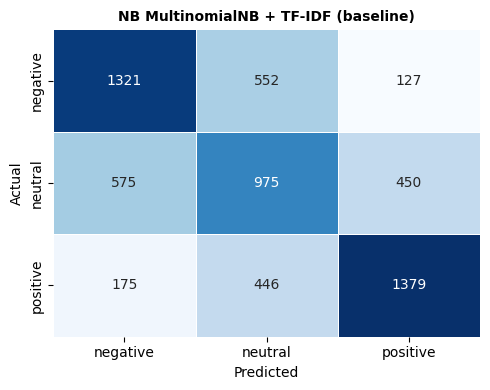


  NB GaussianNB + Word2Vec (baseline)
  Accuracy  : 0.5595  |  F1-Macro : 0.5597

              precision    recall  f1-score   support

    negative       0.60      0.55      0.58      2000
     neutral       0.45      0.47      0.46      2000
    positive       0.63      0.66      0.64      2000

    accuracy                           0.56      6000
   macro avg       0.56      0.56      0.56      6000
weighted avg       0.56      0.56      0.56      6000



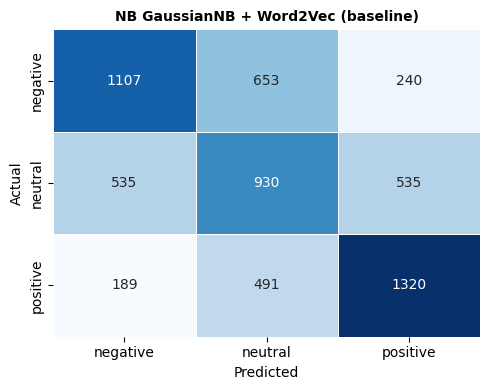

In [9]:
# TF-IDF → MultinomialNB (non-negative sparse matrix ✅)
r = evaluate_model(MultinomialNB(alpha=0.5),
                   X_train_tfidf, X_test_tfidf, y_train, y_test,
                   vectorizer=tfidf, model_name="NB MultinomialNB + TF-IDF (baseline)")
all_results.append(r)

# Word2Vec → GaussianNB (real-valued dense vectors ✅)
r = evaluate_model(GaussianNB(),
                   X_train_w2v, X_test_w2v, y_train, y_test,
                   model_name="NB GaussianNB + Word2Vec (baseline)")
all_results.append(r)


### Baseline Summary

In [10]:
print("\n" + "="*72)
print("  BASELINE PERFORMANCE SUMMARY")
print("="*72)
print(f"{'Model':<40} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8}")
print("-"*72)
for r in all_results:
    print(f"{r['name']:<40} {r['acc']:>8.4f} {r['prec']:>8.4f} {r['rec']:>8.4f} {r['f1_macro']:>8.4f}")



  BASELINE PERFORMANCE SUMMARY
Model                                         Acc     Prec      Rec       F1
------------------------------------------------------------------------
LR + TF-IDF (baseline)                     0.6328   0.6319   0.6328   0.6320
LR + Word2Vec (baseline)                   0.6025   0.5993   0.6025   0.6005
SVM + TF-IDF (baseline)                    0.6008   0.5966   0.6008   0.5982
SVM + Word2Vec (baseline)                  0.5983   0.5872   0.5983   0.5870
NB MultinomialNB + TF-IDF (baseline)       0.6125   0.6123   0.6125   0.6123
NB GaussianNB + Word2Vec (baseline)        0.5595   0.5610   0.5595   0.5597


## Hyperparameter Tuning & Transformer Fine-tuning

In [11]:
def tune_and_evaluate(model_factory, param_grid,
                      X_train, X_test, y_train, y_test,
                      vectorizer=None, model_name="Model"):
    """GridSearchCV wrapper. model_factory is a zero-arg callable returning a fresh estimator."""
    grid = GridSearchCV(
        model_factory(), param_grid,
        cv=3, scoring="f1_macro", n_jobs=-1, verbose=0
    )
    grid.fit(X_train, y_train)
    print(f"\n🔍  {model_name}")
    print(f"    Best params : {grid.best_params_}")
    print(f"    CV F1-macro : {grid.best_score_:.4f}")
    r = evaluate_model(
        grid.best_estimator_, X_train, X_test, y_train, y_test,
        vectorizer=vectorizer, model_name=f"{model_name} (tuned)"
    )
    return grid.best_estimator_, r

tuned_results = []
print("✅  tune_and_evaluate defined.")


✅  tune_and_evaluate defined.


### Logistic Regression — Tuned


🔍  Logistic Regression (TF-IDF)
    Best params : {'C': 1, 'solver': 'saga'}
    CV F1-macro : 0.6271

  Logistic Regression (TF-IDF) (tuned)
  Accuracy  : 0.6323  |  F1-Macro : 0.6316

              precision    recall  f1-score   support

    negative       0.66      0.70      0.68      2000
     neutral       0.52      0.50      0.51      2000
    positive       0.72      0.70      0.71      2000

    accuracy                           0.63      6000
   macro avg       0.63      0.63      0.63      6000
weighted avg       0.63      0.63      0.63      6000



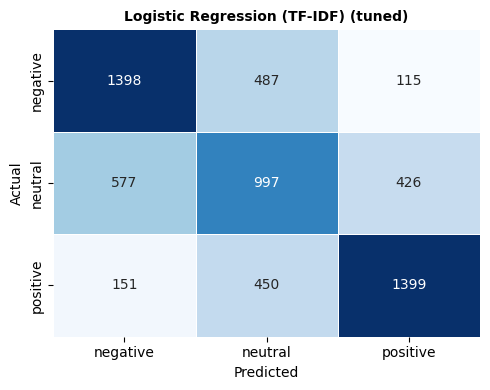


🔍  Logistic Regression (Word2Vec)
    Best params : {'C': 0.1, 'solver': 'lbfgs'}
    CV F1-macro : 0.6091

  Logistic Regression (Word2Vec) (tuned)
  Accuracy  : 0.6047  |  F1-Macro : 0.6024

              precision    recall  f1-score   support

    negative       0.64      0.68      0.66      2000
     neutral       0.49      0.45      0.47      2000
    positive       0.68      0.68      0.68      2000

    accuracy                           0.60      6000
   macro avg       0.60      0.60      0.60      6000
weighted avg       0.60      0.60      0.60      6000



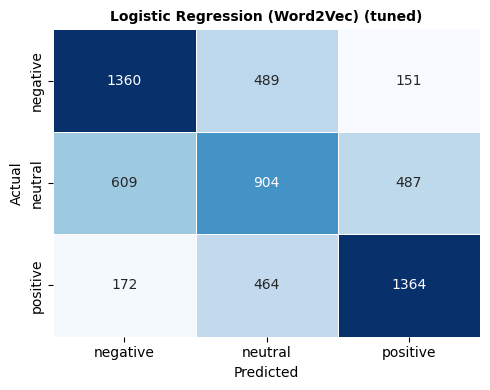

In [12]:
param_lr = {"C": [0.01, 0.1, 1, 10], "solver": ["lbfgs", "saga"]}

best_lr_tfidf, r = tune_and_evaluate(
    lambda: LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    param_lr, X_train_tfidf, X_test_tfidf, y_train, y_test,
    vectorizer=tfidf, model_name="Logistic Regression (TF-IDF)")
tuned_results.append(r)

best_lr_w2v, r = tune_and_evaluate(
    lambda: LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    param_lr, X_train_w2v, X_test_w2v, y_train, y_test,
    model_name="Logistic Regression (Word2Vec)")
tuned_results.append(r)


### Linear SVM — Tuned


🔍  Linear SVM (TF-IDF)
    Best params : {'C': 0.1}
    CV F1-macro : 0.6193

  Linear SVM (TF-IDF) (tuned)
  Accuracy  : 0.6337  |  F1-Macro : 0.6282

              precision    recall  f1-score   support

    negative       0.64      0.73      0.68      2000
     neutral       0.54      0.45      0.49      2000
    positive       0.71      0.73      0.72      2000

    accuracy                           0.63      6000
   macro avg       0.63      0.63      0.63      6000
weighted avg       0.63      0.63      0.63      6000



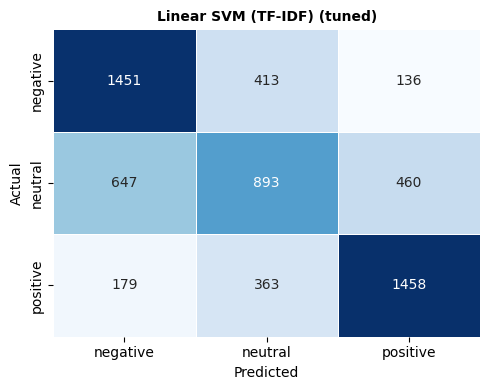


🔍  Linear SVM (Word2Vec)
    Best params : {'C': 1}
    CV F1-macro : 0.5914

  Linear SVM (Word2Vec) (tuned)
  Accuracy  : 0.5983  |  F1-Macro : 0.5870

              precision    recall  f1-score   support

    negative       0.61      0.72      0.66      2000
     neutral       0.50      0.36      0.42      2000
    positive       0.65      0.71      0.68      2000

    accuracy                           0.60      6000
   macro avg       0.59      0.60      0.59      6000
weighted avg       0.59      0.60      0.59      6000



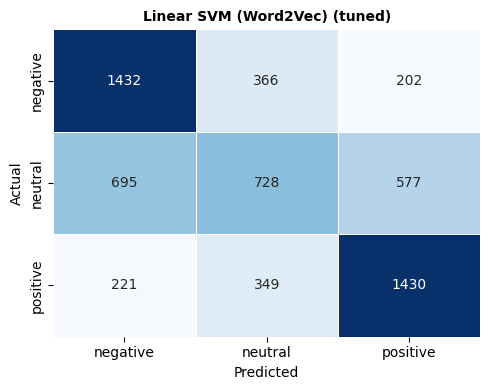

In [13]:
param_svm = {"C": [0.1, 1, 10]}

best_svm_tfidf, r = tune_and_evaluate(
    lambda: LinearSVC(class_weight="balanced", max_iter=3000, random_state=42),
    param_svm, X_train_tfidf, X_test_tfidf, y_train, y_test,
    vectorizer=tfidf, model_name="Linear SVM (TF-IDF)")
tuned_results.append(r)

best_svm_w2v, r = tune_and_evaluate(
    lambda: LinearSVC(class_weight="balanced", max_iter=3000, random_state=42),
    param_svm, X_train_w2v, X_test_w2v, y_train, y_test,
    model_name="Linear SVM (Word2Vec)")
tuned_results.append(r)


### Naive Bayes — Tuned


🔍  NB MultinomialNB (TF-IDF)
    Best params : {'alpha': 5.0}
    CV F1-macro : 0.6247

  NB MultinomialNB (TF-IDF) (tuned)
  Accuracy  : 0.6165  |  F1-Macro : 0.6179

              precision    recall  f1-score   support

    negative       0.65      0.65      0.65      2000
     neutral       0.49      0.52      0.50      2000
    positive       0.71      0.69      0.70      2000

    accuracy                           0.62      6000
   macro avg       0.62      0.62      0.62      6000
weighted avg       0.62      0.62      0.62      6000



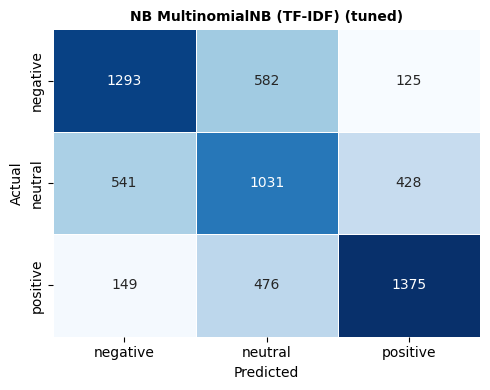


🔍  NB GaussianNB (Word2Vec)
    Best params : {'var_smoothing': 1e-09}
    CV F1-macro : 0.5620

  NB GaussianNB (Word2Vec) (tuned)
  Accuracy  : 0.5595  |  F1-Macro : 0.5597

              precision    recall  f1-score   support

    negative       0.60      0.55      0.58      2000
     neutral       0.45      0.47      0.46      2000
    positive       0.63      0.66      0.64      2000

    accuracy                           0.56      6000
   macro avg       0.56      0.56      0.56      6000
weighted avg       0.56      0.56      0.56      6000



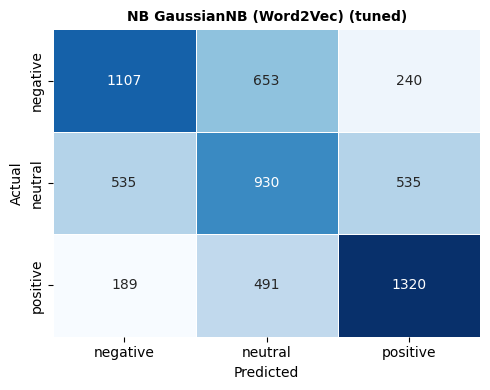

In [14]:
# TF-IDF: MultinomialNB
param_nb_tfidf = {"alpha": [0.1, 0.5, 1.0, 5.0]}
best_nb_tfidf, r = tune_and_evaluate(
    MultinomialNB, param_nb_tfidf,
    X_train_tfidf, X_test_tfidf, y_train, y_test,
    vectorizer=tfidf, model_name="NB MultinomialNB (TF-IDF)")
tuned_results.append(r)

# Word2Vec: GaussianNB
param_nb_w2v = {"var_smoothing": [1e-9, 1e-8, 1e-7]}
best_nb_w2v, r = tune_and_evaluate(
    GaussianNB, param_nb_w2v,
    X_train_w2v, X_test_w2v, y_train, y_test,
    model_name="NB GaussianNB (Word2Vec)")
tuned_results.append(r)


### Transformer — BERT Fine-tuning (`distilbert-base-uncased`)

We fine-tune **DistilBERT** (a lightweight BERT variant) end-to-end on the same
train/test split used by all other models, so results are directly comparable.

The transformer operates on `review_text` (raw text) — not `cleaned_text` —
because BERT's WordPiece tokeniser handles punctuation and casing itself.
Preprocessing (stopword removal, stemming) would hurt performance here.

**Training config:** 3 epochs · batch size 16 · AdamW · linear warmup schedule  
**Hardware note:** GPU recommended; CPU training works but is slower (~10–20 min).


In [15]:
# Install if not already present (comment out if already installed)
# !pip install transformers datasets accelerate torch -q

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from torch.optim import AdamW as TorchAdamW

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME = "distilbert-base-uncased"
MAX_LEN    = 128   # token limit per review (covers >95% of reviews in this dataset)
BATCH_SIZE = 16
EPOCHS     = 3
LR         = 2e-5

print(f"✅  PyTorch  : {torch.__version__}")
print(f"    Device  : {DEVICE}")
print(f"    Model   : {MODEL_NAME}")


✅  PyTorch  : 2.7.0+cpu
    Device  : cpu
    Model   : distilbert-base-uncased


In [16]:
# ── Tokeniser ─────────────────────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Use raw review_text for BERT (not cleaned_text — BERT handles its own tokenisation)
raw_train_texts = df["review_text"].values[train_pos].tolist()
raw_test_texts  = df["review_text"].values[test_pos].tolist()

class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(
            texts,
            padding="max_length",
            truncation=True,
            max_length=max_len,
            return_tensors="pt",
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids":      self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels":         self.labels[idx],
        }

train_dataset = ReviewDataset(raw_train_texts, y_train.tolist(), tokenizer, MAX_LEN)
test_dataset  = ReviewDataset(raw_test_texts,  y_test.tolist(),  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"✅  Tokenised  |  Train batches : {len(train_loader)}  |  Test batches : {len(test_loader)}")


✅  Tokenised  |  Train batches : 1500  |  Test batches : 375


In [17]:
# ── Model, optimiser, scheduler ───────────────────────────────────────────
num_labels = len(LABELS)
bert_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=num_labels
).to(DEVICE)

optimizer = TorchAdamW(bert_model.parameters(), lr=LR, weight_decay=0.01)

total_steps   = len(train_loader) * EPOCHS
warmup_steps  = int(0.1 * total_steps)   # 10% warmup
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f"✅  Model loaded  |  Parameters : {sum(p.numel() for p in bert_model.parameters()):,}")
print(f"    Total steps : {total_steps}  |  Warmup steps : {warmup_steps}")


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3081.03it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅  Model loaded  |  Parameters : 66,955,779
    Total steps : 4500  |  Warmup steps : 450


  Epoch 1/3  |  Avg loss : 0.7873
  Epoch 2/3  |  Avg loss : 0.6290
  Epoch 3/3  |  Avg loss : 0.5061


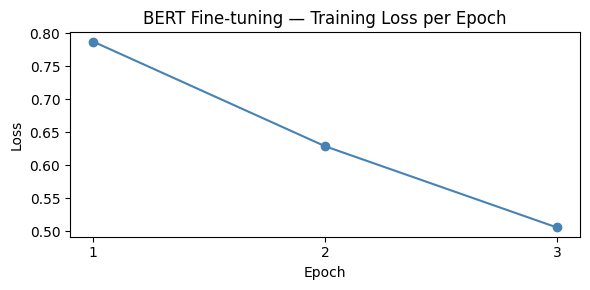

✅  Training complete.


In [18]:
# ── Training loop ─────────────────────────────────────────────────────────
bert_model.train()
train_losses = []

for epoch in range(EPOCHS):
    epoch_loss = 0.0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels         = batch["labels"].to(DEVICE)

        outputs = bert_model(input_ids=input_ids,
                             attention_mask=attention_mask,
                             labels=labels)
        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"  Epoch {epoch+1}/{EPOCHS}  |  Avg loss : {avg_loss:.4f}")

# Plot training loss
plt.figure(figsize=(6, 3))
plt.plot(range(1, EPOCHS + 1), train_losses, marker="o", color="steelblue")
plt.title("BERT Fine-tuning — Training Loss per Epoch")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.xticks(range(1, EPOCHS + 1))
plt.tight_layout(); plt.show()
print("✅  Training complete.")



  DistilBERT (fine-tuned)
  Accuracy  : 0.6898  |  F1-Macro : 0.6927

              precision    recall  f1-score   support

    negative       0.73      0.73      0.73      2000
     neutral       0.56      0.62      0.59      2000
    positive       0.80      0.71      0.76      2000

    accuracy                           0.69      6000
   macro avg       0.70      0.69      0.69      6000
weighted avg       0.70      0.69      0.69      6000



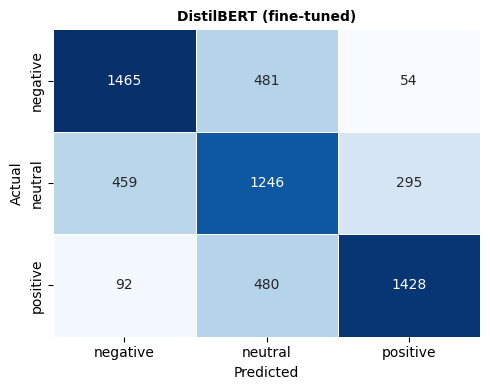

✅  bert_result added to tuned_results.


In [19]:
# ── Evaluation on test set ────────────────────────────────────────────────
bert_model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels         = batch["labels"].to(DEVICE)

        outputs  = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        preds    = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_true.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_true  = np.array(all_true)

# ── Metrics ────────────────────────────────────────────────────────────────
acc  = accuracy_score(all_true, all_preds)
prec = precision_score(all_true, all_preds, average="macro", zero_division=0)
rec  = recall_score   (all_true, all_preds, average="macro", zero_division=0)
f1m  = f1_score       (all_true, all_preds, average="macro", zero_division=0)
cm   = confusion_matrix(all_true, all_preds)
cr   = classification_report(all_true, all_preds, target_names=LABELS, zero_division=0)

print(f"\n{'='*55}")
print(f"  DistilBERT (fine-tuned)")
print(f"{'='*55}")
print(f"  Accuracy  : {acc:.4f}  |  F1-Macro : {f1m:.4f}")
print(f"\n{cr}")

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=LABELS, yticklabels=LABELS,
            linewidths=0.5, ax=ax, cbar=False)
ax.set_title("DistilBERT (fine-tuned)", fontsize=10, fontweight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.show()

# Store result in same format as all other models
bert_result = {
    "name":     "DistilBERT (fine-tuned)",
    "clf":      bert_model,
    "y_pred":   all_preds,
    "acc":      acc,
    "prec":     prec,
    "rec":      rec,
    "f1_macro": f1m,
    "cm":       cm,
    "report":   cr,
}
tuned_results.append(bert_result)
print("✅  bert_result added to tuned_results.")


In [20]:
# ── Error analysis for BERT ────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"  ERROR ANALYSIS — DistilBERT (fine-tuned)")
print(f"{'='*55}")

bert_preds = bert_result["y_pred"]
mis = np.where(bert_preds != all_true)[0]
print(f"  Total misclassified : {len(mis):,}  |  Showing {min(10, len(mis))}\n")

for k, pos in enumerate(mis[:10]):
    true_label = le.inverse_transform([all_true[pos]])[0]
    pred_label = le.inverse_transform([bert_preds[pos]])[0]
    orig_idx   = test_pos[pos]
    review     = df.iloc[orig_idx]["cleaned_text"]
    rating     = df.iloc[orig_idx]["rating"]
    print(f"  [{k+1:02d}]  TRUE: {true_label:<10}  PRED: {pred_label:<10}  Rating: {rating}")
    print(f"       {str(review)[:250]}")
    print()



  ERROR ANALYSIS — DistilBERT (fine-tuned)
  Total misclassified : 1,861  |  Showing 10

  [01]  TRUE: neutral     PRED: negative    Rating: 3
       game really good get level could n't save anything would n't let well surprise surprise lose connection progress lose not join match 'm level account still exist really frustrate enjoy game alot

  [02]  TRUE: negative    PRED: neutral     Rating: 2
       game great really want play new airship map unfortunately new update come problem no longer type kind chat lobby game not refuse allow use account problem googleauthnotoken could fix 'd magnanimous

  [03]  TRUE: negative    PRED: neutral     Rating: 2
       minecraft please fix game 'm try join hive always disconnect host say server not find please answer

  [04]  TRUE: positive    PRED: negative    Rating: 4
       ton problem first server awful know already second gym battle never work may not even get gym spend minute battle way three trainer nobody another team take gym get victo

In [ ]:
SAVE_PATH = r"C:\Users\hp\Desktop\Python_Workspace\NLP CSAI 452\project\distilbert_sentiment"
os.makedirs(SAVE_PATH, exist_ok=True)
bert_model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)
print(f"✅ Model saved → {SAVE_PATH}/")
print(f"   To reload: AutoModelForSequenceClassification.from_pretrained('{SAVE_PATH}')")

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.06s/it]

✅ Model saved → C:\Users\hp\Desktop\Python_Workspace\NLP CSAI 452\project\distilbert_sentiment/
   To reload: AutoModelForSequenceClassification.from_pretrained('C:\Users\hp\Desktop\Python_Workspace\NLP CSAI 452\project\distilbert_sentiment')


### Tuned Summary (including BERT)

In [22]:
print("\n" + "="*72)
print("  TUNED MODEL PERFORMANCE SUMMARY")
print("="*72)
print(f"{'Model':<42} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8}")
print("-"*72)
for r in tuned_results:
    print(f"{r['name']:<42} {r['acc']:>8.4f} {r['prec']:>8.4f} {r['rec']:>8.4f} {r['f1_macro']:>8.4f}")

best_tuned = max(tuned_results, key=lambda r: r["f1_macro"])
print(f"\n🏆  Best tuned model : {best_tuned['name']}  (F1-macro = {best_tuned['f1_macro']:.4f})")



  TUNED MODEL PERFORMANCE SUMMARY
Model                                           Acc     Prec      Rec       F1
------------------------------------------------------------------------
Logistic Regression (TF-IDF) (tuned)         0.6323   0.6314   0.6323   0.6316
Logistic Regression (Word2Vec) (tuned)       0.6047   0.6011   0.6047   0.6024
Linear SVM (TF-IDF) (tuned)                  0.6337   0.6274   0.6337   0.6282
Linear SVM (Word2Vec) (tuned)                0.5983   0.5872   0.5983   0.5870
NB MultinomialNB (TF-IDF) (tuned)            0.6165   0.6196   0.6165   0.6179
NB GaussianNB (Word2Vec) (tuned)             0.5595   0.5610   0.5595   0.5597
DistilBERT (fine-tuned)                      0.6898   0.6983   0.6898   0.6927

🏆  Best tuned model : DistilBERT (fine-tuned)  (F1-macro = 0.6927)


## Combined Confusion Matrix Grid — All Tuned Models

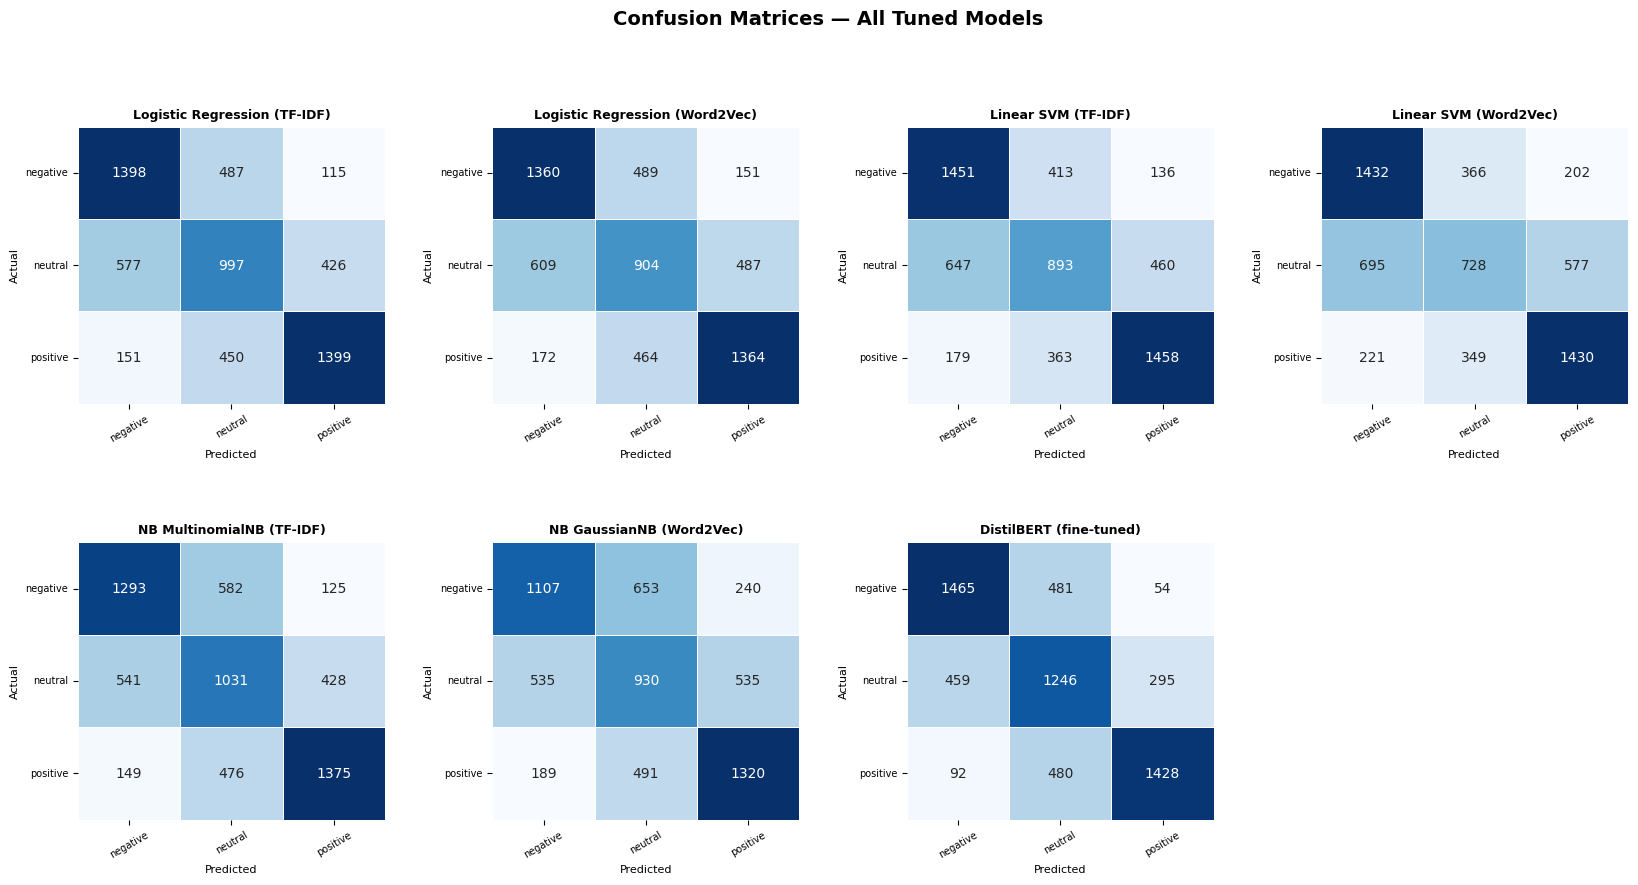

✅  Saved → confusion_matrices.png


In [23]:
n_models = len(tuned_results)
cols = 4
rows = (n_models + cols - 1) // cols

fig = plt.figure(figsize=(5 * cols, 4.5 * rows))
fig.suptitle("Confusion Matrices — All Tuned Models", fontsize=14, fontweight="bold", y=1.01)
gs  = gridspec.GridSpec(rows, cols, figure=fig, hspace=0.5, wspace=0.35)

for idx, r in enumerate(tuned_results):
    row, col = divmod(idx, cols)
    ax = fig.add_subplot(gs[row, col])
    sns.heatmap(r["cm"], annot=True, fmt="d", cmap="Blues",
                xticklabels=LABELS, yticklabels=LABELS,
                linewidths=0.5, ax=ax, cbar=False)
    ax.set_title(r["name"].replace(" (tuned)", ""), fontsize=9, fontweight="bold")
    ax.set_xlabel("Predicted", fontsize=8)
    ax.set_ylabel("Actual",    fontsize=8)
    ax.tick_params(axis="x", rotation=30, labelsize=7)
    ax.tick_params(axis="y", rotation=0,  labelsize=7)

plt.savefig("confusion_matrices.png", bbox_inches="tight", dpi=150)
plt.show()
print("✅  Saved → confusion_matrices.png")


## Top Features — Linear Models (TF-IDF)

Logistic Regression and LinearSVC expose per-class coefficient vectors that map
directly to TF-IDF vocabulary indices, revealing the most predictive n-grams.


In [24]:
show_top_features(best_lr_tfidf,  tfidf, "Logistic Regression (TF-IDF) — Tuned")
show_top_features(best_svm_tfidf, tfidf, "Linear SVM (TF-IDF) — Tuned")



  TOP FEATURES — Logistic Regression (TF-IDF) — Tuned

  [NEGATIVE]
    Most positive : worst, terrible, horrible, worse, money, one star, ruin, trash, disappoint, stupid, anymore, waste, not, awful, useless
    Most negative : love, great, amaze, fun, good, best, awesome, good game, great game, sometimes, pretty, perfect, nice, thank, best game

  [NEUTRAL]
    Most positive : three star, three, game good, least, please, not bad, decent, give three, ok, display, didnt, game fun, setting, okay, fun game
    Most negative : one star, recommend, finally, smooth, worth, patience, ever, easy, download, much fun, wonder, never, genuinely, negative, get better

  [POSITIVE]
    Most positive : love, amaze, best, great, awesome, fun, good, perfect, best game, thank, entertain, great game, nice, addict, amaze game
    Most negative : ruin, worst, not, horrible, disappoint, anymore, suck, matchmaking, terrible, worse, waste, use love, bad, use, frustrate

  TOP FEATURES — Linear SVM (TF-IDF) —

## Error Analysis — Best Tuned Models

Inspect 10 misclassified reviews to identify systematic failure patterns.
The `rating` column from the original data is shown alongside each example.


In [25]:
error_analysis(best_lr_tfidf, X_test_tfidf, y_test,
               model_name="Logistic Regression (TF-IDF) — Tuned", n=10)

error_analysis(best_lr_w2v, X_test_w2v, y_test,
               model_name="Logistic Regression (Word2Vec) — Tuned", n=10)



  ERROR ANALYSIS — Logistic Regression (TF-IDF) — Tuned
  Total misclassified : 2,206  |  Showing 10

  [01]  TRUE: neutral     PRED: negative    Rating: 3
       game really good get level could n't save anything would n't let well surprise surprise lose connection progress lose not join match 'm level account still exist really frustrate enjoy game alot

  [02]  TRUE: neutral     PRED: negative    Rating: 3
       reason 'm give star game crash game since last two update crash game snapdragon power realme pro 's become annoy fix 'm gon na uninstall straight away

  [03]  TRUE: negative    PRED: neutral     Rating: 2
       love play game especially lore exploration 's no longer playable due lag always spike m server need fix one thing demotivates drain lot play genshin 's really unrewarding might spend lot time 'll end primogems game currency barely enough single maybe

  [04]  TRUE: negative    PRED: neutral     Rating: 2
       minecraft please fix game 'm try join hive always dis

## Error Discussion

Common failure patterns based on the `cleaned_text`, `label`, and `rating` columns:

1. **Neutral ↔ Positive confusion** — Mixed reviews (rating 3–4) contain positive vocabulary
   ("fun", "good") alongside complaints; the model favours the positive lexicon.

2. **Neutral ↔ Negative confusion** — Short negative reviews yield sparse TF-IDF vectors and
   W2V averages close to the neutral centroid.

3. **Irony / sarcasm** — Phrases that are lexically positive but contextually negative
   (e.g., *"great job breaking the game again"*) fool bag-of-words representations.

4. **Rating–label mismatch** — A rating-3 review may read positive or negative depending on
   the user's phrasing, introducing ground-truth noise.

5. **Rare vocabulary** — Words absent from the training corpus produce zero W2V vectors,
   reducing document representation quality for short or specialised reviews.


## Save Full Results Report → `results_summary.txt`

In [26]:
SEP = "=" * 65
lines = [SEP, "  SENTIMENT ANALYSIS — FULL RESULTS REPORT", SEP]

lines += ["\n── DATA SUMMARY ─────────────────────────────────────────────"]
lines += [df["label"].value_counts().to_string()]
lines += [f"\n  Total samples : {len(df):,}",
          f"  Train / Test  : {len(X_train_text):,} / {len(X_test_text):,}  (80/20 stratified)"]

lines += ["\n\n── BASELINE PERFORMANCE ────────────────────────────────────"]
lines += [f"{'Model':<40} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8}", "-"*65]
for r in all_results:
    lines.append(f"{r['name']:<40} {r['acc']:>8.4f} {r['prec']:>8.4f} {r['rec']:>8.4f} {r['f1_macro']:>8.4f}")

lines += ["\n\n── TUNED PERFORMANCE ───────────────────────────────────────"]
lines += [f"{'Model':<42} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8}", "-"*65]
for r in tuned_results:
    lines.append(f"{r['name']:<42} {r['acc']:>8.4f} {r['prec']:>8.4f} {r['rec']:>8.4f} {r['f1_macro']:>8.4f}")

best_tuned = max(tuned_results, key=lambda r: r["f1_macro"])
lines += [f"\n\n── BEST MODEL ──────────────────────────────────────────────",
          f"  {best_tuned['name']}  (F1-macro = {best_tuned['f1_macro']:.4f})"]

lines += ["\n\n── PER-CLASS REPORTS (TUNED) ────────────────────────────────"]
for r in tuned_results:
    lines += [f"\n{'─'*40}", f"  {r['name']}", f"{'─'*40}", r["report"]]

lines += [SEP, "  END OF REPORT", SEP]

report_text = "\n".join(lines)
with open("results_summary.txt", "w", encoding="utf-8") as f:
    f.write(report_text)

print(report_text)
print("\n✅  Saved → results_summary.txt")
print("✅  Saved → confusion_matrices.png")


  SENTIMENT ANALYSIS — FULL RESULTS REPORT

── DATA SUMMARY ─────────────────────────────────────────────
label
negative    10000
positive    10000
neutral     10000

  Total samples : 30,000
  Train / Test  : 24,000 / 6,000  (80/20 stratified)


── BASELINE PERFORMANCE ────────────────────────────────────
Model                                         Acc     Prec      Rec       F1
-----------------------------------------------------------------
LR + TF-IDF (baseline)                     0.6328   0.6319   0.6328   0.6320
LR + Word2Vec (baseline)                   0.6025   0.5993   0.6025   0.6005
SVM + TF-IDF (baseline)                    0.6008   0.5966   0.6008   0.5982
SVM + Word2Vec (baseline)                  0.5983   0.5872   0.5983   0.5870
NB MultinomialNB + TF-IDF (baseline)       0.6125   0.6123   0.6125   0.6123
NB GaussianNB + Word2Vec (baseline)        0.5595   0.5610   0.5595   0.5597


── TUNED PERFORMANCE ───────────────────────────────────────
Model                   